# Analytical Velocity

$\
W_{\mathrm{c}} = \frac{2.07 \cdot Ek_c}{R_1} \cdot \mathrm{e}^{\,2.3026 \frac{x}{R_1}}
\
$

$
\text{AV}= Ek_{\text{pump}} + W_c
$

where $AV$ is in $ms^{-1}$ , $e$ is the Euler number and $x$ is the distance to the coast. 

* Wc is computed from the cross-shore Ekman transport evaluated at the coastline, and distributed offshore following an exponential decay over the first baroclinic Rossby radius $R_1$, such that $w_c$ reaches 10% of its coastal value at $x=R_1$ (Bordbar et al. 2021; Fennel 1999).
* Is important to take into consideration that in Boardbar paper, the coastal angle for Benguela is close to $0^{\circ}$ with the North, for which the rotation done is not needed there, and we will use the Uekman non rotated but geographical transport for building this index. However when the rotation is effective the Analytical velocity wouldn't work for the Peruvian Sea which angle is $45^{\circ}$

In [1]:
import xarray as xr
from scipy.ndimage import binary_erosion, binary_dilation
import math
import numpy as np

## Functions

In [2]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [3]:
def coastal_band_mask_rossby(ds, var='u10', R1=None):
    """
    Create a coastal band mask where the width at each latitude
    equals the local first baroclinic Rossby radius.

    Parameters
    ----------
    ds : xr.Dataset
    var : str
    R1 : xr.DataArray
        Rossby radius in km with a 'lat' coordinate.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])

    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        i_coast = ocean_cols[-1]

        # Interpolate R1 to this latitude
        target_width_km = float(R1.interp(lat=lat_vals[j], method='nearest'))
        if np.isnan(target_width_km):
            continue

        A = 6371.0
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [4]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Data

In [5]:
lati1,lati2=-4,-17
mask_km = 250

In [6]:
R_X = xr.open_dataset('../Rossby_radius_and_X.nc').compute()
mask = coastal_band_mask(R_X, var='R', target_width_km=mask_km)

In [7]:
R_X = R_X.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1)) 
R_X

<xarray.Dataset> Size: 496kB
Dimensions:  (lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    R        (lat, lon) float64 247kB nan nan nan nan nan ... nan nan nan nan
    X        (lat, lon) float64 247kB nan nan nan nan nan ... nan nan nan nan

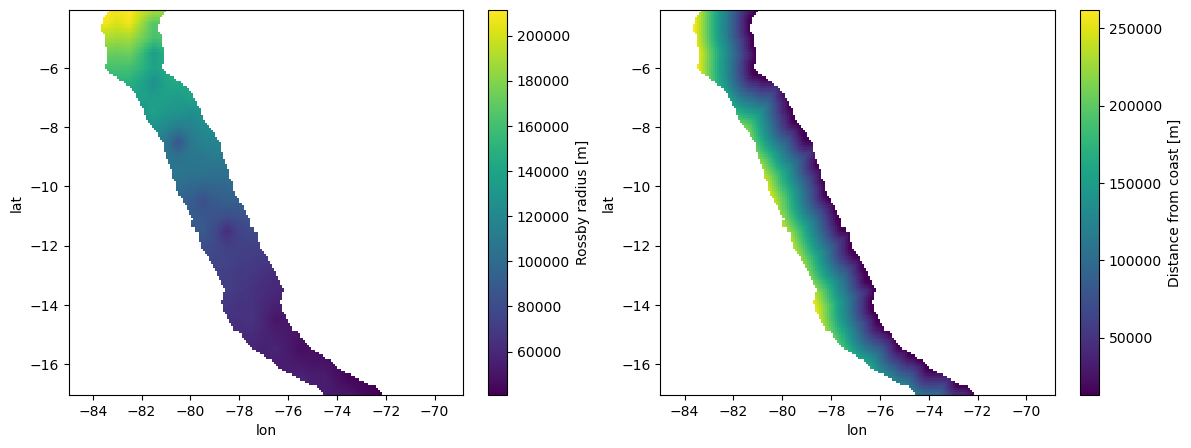

In [8]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize=(14,5))
R_X.R.plot(ax=ax[0])
R_X.X.plot(ax=ax[1])

<xarray.DataArray 'R' ()> Size: 8B
array(96.39894702)


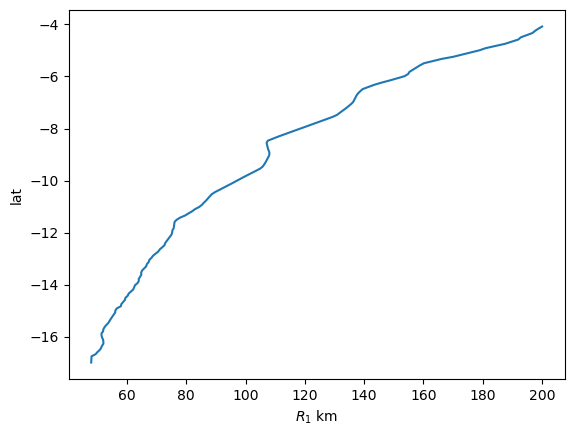

In [9]:
(R_X/1000).R.mean('lon').rename('$R_1$ km').plot(y='lat')

print((R_X/1000).R.mean('lon').sel(lat=slice(-16,-5)).mean())

In [10]:
R_lati = (R_X/1000).R.mean('lon')

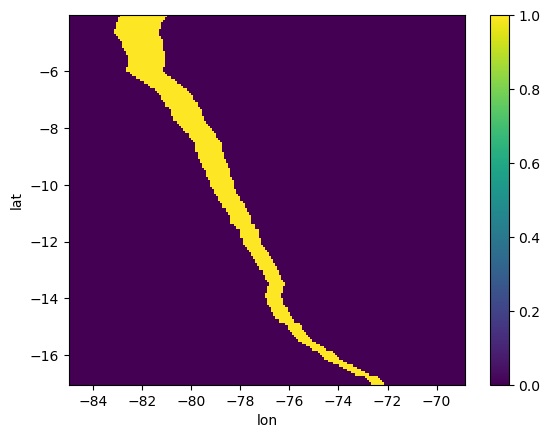

In [11]:
mask_rossby = coastal_band_mask_rossby(R_X, var='R', R1=R_lati)
mask_rossby.plot()

In [12]:
#### Inshore
valid = xr.where(np.isfinite(R_X.R), 1, 0)
valid_w = valid.shift(lon=-1) #west
# Boolean mask of valid ocean cells
valid_in = xr.where(np.isfinite(R_X.R), 1, 0)
# valid_e = valid.shift(lon=+1)  # east

inshore_mask = (valid_in == 1) & (valid_w == 0)

R_inshore = R_X.R.where(inshore_mask)

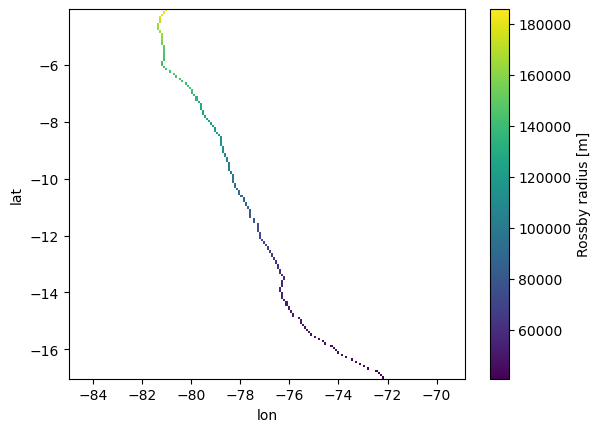

In [13]:
R_inshore.plot()

In [14]:
winds_c = xr.open_dataset('Winds_components_Lu.nc').compute()
winds_c

<xarray.Dataset> Size: 89MB
Dimensions:          (time: 432, coast_point: 159, offshore: 27)
Coordinates:
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * coast_point      (coast_point) int64 1kB 0 1 2 3 4 5 ... 154 155 156 157 158
  * offshore         (offshore) int64 216B 0 1 2 3 4 5 6 ... 21 22 23 24 25 26
    lat              (coast_point, offshore) float64 34kB -16.99 ... -4.079
    lon              (coast_point, offshore) float64 34kB -74.45 ... -81.12
    bearing          (coast_point) float64 1kB 135.0 135.0 135.0 ... 45.0 45.0
    distance         (coast_point, offshore) float64 34kB 2.393e+05 ... 9.243...
    f                (coast_point, offshore) float64 34kB -4.262e-05 ... -1.0...
Data variables:
    wind_alongshore  (time, coast_point, offshore) float64 15MB 5.468 ... 5.925
    tau_alongshore   (time, coast_point, offshore) float64 15MB 0.04803 ... 0...
    etransport       (time, coast_point, offshore) float64 15MB 4.595e-06 ......
    epumping         (time, coast_point, offshore) float64 15MB 1.761e-06 ......
    Ek_layer_D       (time, coast_point, offshore) float64 15MB 44.05 ... 99.58
    U_ek_cross       (time, coast_point, offshore) float64 15MB 1.099 ... 5.458
Attributes:
    description:  Alongshore winds, Ekman transport and pumping (NHUS, 5°S–16°S)

In [15]:
Uek_inshore = (winds_c.U_ek_cross
        .isel(offshore=0)
        .swap_dims({'coast_point': 'lat'})
        .drop_vars(['coast_point', 'lon', 'bearing', 'distance', 'f', 'offshore']))
Uek_inshore

<xarray.DataArray 'U_ek_cross' (time: 432, lat: 159)> Size: 550kB
array([[1.09936991, 1.13629932, 1.18267682, ..., 1.38029691, 1.4905408 ,
        1.61628462],
       [0.98497617, 1.00166065, 1.03502389, ..., 0.55176081, 0.63042936,
        0.72468545],
       [0.95796447, 0.97392853, 1.00368189, ..., 0.09567068, 0.16782467,
        0.24495986],
       ...,
       [1.64549395, 1.69826302, 1.7661083 , ..., 2.96548421, 3.08481632,
        3.21032296],
       [1.59706691, 1.64387749, 1.70237792, ..., 2.94121349, 3.10352424,
        3.27706339],
       [1.38111402, 1.43295952, 1.4955133 , ..., 2.54178771, 2.66900788,
        2.80614894]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Attributes:
    units:      m^2/s
    long_name:  Cross-shore Ekman transport (BUI)

In [16]:
# R_X = R_X.mean(dim=('lon'))
R_X

<xarray.Dataset> Size: 496kB
Dimensions:  (lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    R        (lat, lon) float64 247kB nan nan nan nan nan ... nan nan nan nan
    X        (lat, lon) float64 247kB nan nan nan nan nan ... nan nan nan nan

In [17]:
e =math.e
# r= R_inshore.mean('lon')
r=R_X.R
x= R_X.X
Uek = Uek_inshore

# print(e.shape)
print(r.shape)
print(x.shape)
print(Uek.shape)

(159, 194)
(159, 194)
(432, 159)


In [18]:
Wc = ((2.07 * Uek)/r)*e**(-2.3026*x/r)
Wc #already in m/s

<xarray.DataArray (time: 432, lat: 159, lon: 194)> Size: 107MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

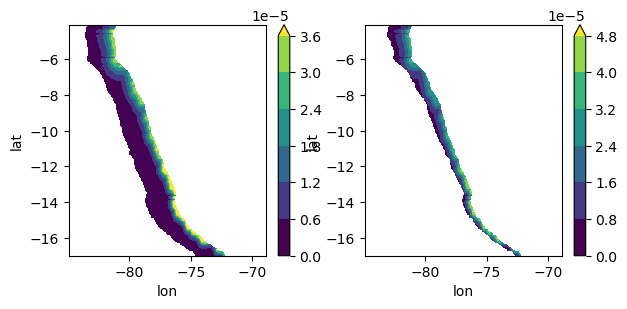

In [19]:
fig,ax =plt.subplots(1,2,figsize=(7,3))

Wc.mean('time').plot.contourf(robust=True,ax=ax[0])
Wc.where(mask_rossby).mean('time').plot.contourf(robust=True,ax=ax[1])

In [20]:
# Wc = Wc.where(mask_rossby).fillna(0)
# Wc

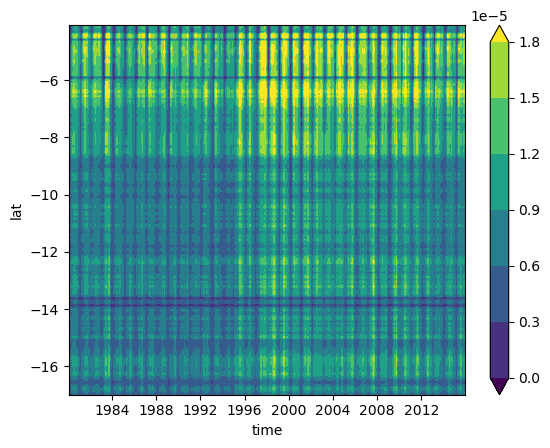

In [21]:
Wc.mean('lon').plot.contourf(x='time',robust=True)

In [100]:
Pump = (winds_c.epumping
        .isel(offshore=slice(0,24))
        .mean('offshore')
        .assign_coords(lat=('coast_point', winds_c.lat.values[:, 0]))
        .swap_dims({'coast_point': 'lat'})
       .drop_vars(['coast_point', 'bearing']))
Pump

<xarray.DataArray 'epumping' (time: 432, lat: 159)> Size: 550kB
array([[1.86116251e-06, 1.97158776e-06, 2.10687202e-06, ...,
        4.34098206e-06, 6.04142282e-06, 1.30919758e-05],
       [1.20476263e-06, 1.27772450e-06, 1.38103555e-06, ...,
        3.30885970e-06, 4.46939595e-06, 9.32769398e-06],
       [1.22514668e-06, 1.30987213e-06, 1.40098605e-06, ...,
        3.61246598e-06, 4.36824450e-06, 7.60595051e-06],
       ...,
       [2.91157525e-06, 2.91720949e-06, 3.00909405e-06, ...,
        3.26894174e-06, 6.35072050e-06, 1.85664188e-05],
       [2.83022955e-06, 2.86345282e-06, 2.95626610e-06, ...,
        2.56809974e-06, 5.82450958e-06, 1.87206096e-05],
       [2.44610064e-06, 2.50366272e-06, 2.63179034e-06, ...,
        4.01858518e-06, 6.63860042e-06, 1.71673071e-05]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079

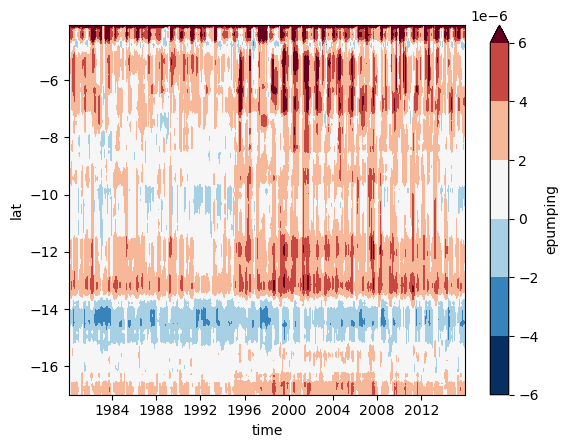

In [101]:
Pump.plot.contourf(x='time',robust=True)

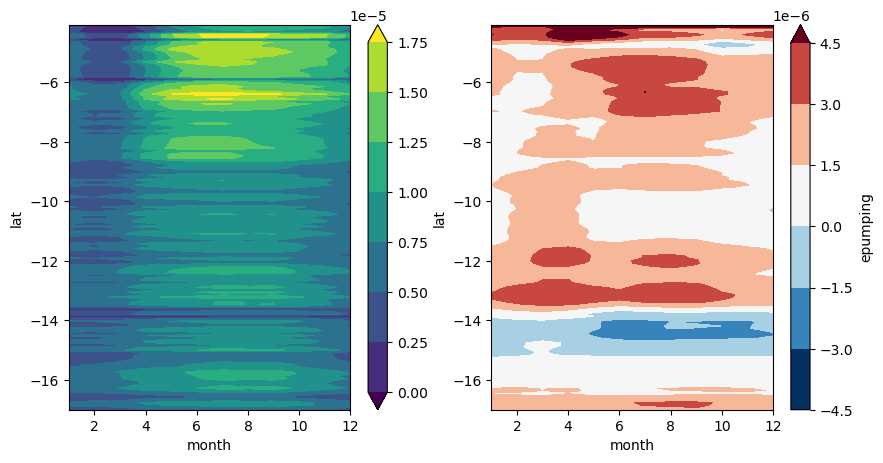

In [102]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
seasonality(Wc.mean('lon')).plot.contourf(x='month',robust=True,ax=ax[0])
seasonality(Pump).plot.contourf(x='month',robust=True,ax=ax[1])

In [103]:
Pump

<xarray.DataArray 'epumping' (time: 432, lat: 159)> Size: 550kB
array([[1.86116251e-06, 1.97158776e-06, 2.10687202e-06, ...,
        4.34098206e-06, 6.04142282e-06, 1.30919758e-05],
       [1.20476263e-06, 1.27772450e-06, 1.38103555e-06, ...,
        3.30885970e-06, 4.46939595e-06, 9.32769398e-06],
       [1.22514668e-06, 1.30987213e-06, 1.40098605e-06, ...,
        3.61246598e-06, 4.36824450e-06, 7.60595051e-06],
       ...,
       [2.91157525e-06, 2.91720949e-06, 3.00909405e-06, ...,
        3.26894174e-06, 6.35072050e-06, 1.85664188e-05],
       [2.83022955e-06, 2.86345282e-06, 2.95626610e-06, ...,
        2.56809974e-06, 5.82450958e-06, 1.87206096e-05],
       [2.44610064e-06, 2.50366272e-06, 2.63179034e-06, ...,
        4.01858518e-06, 6.63860042e-06, 1.71673071e-05]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079

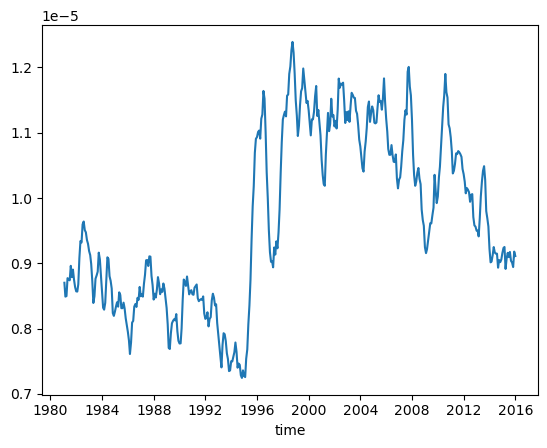

In [104]:
AV = Pump + Wc
AV.mean(dim=('lon','lat')).rolling(time=13).mean().plot()

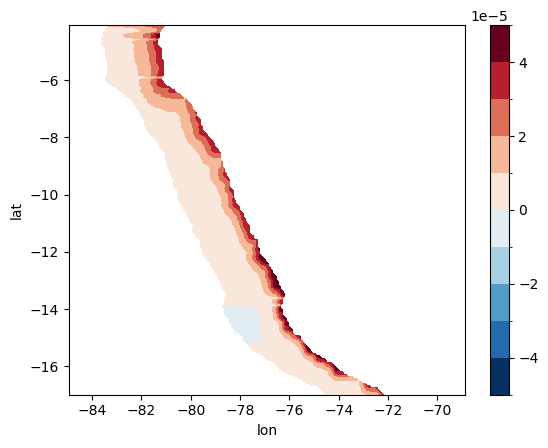

In [105]:
AV.mean('time').plot.contourf(vmin=-5e-5,vmax=5e-5,levels=11,cmap='RdBu_r')

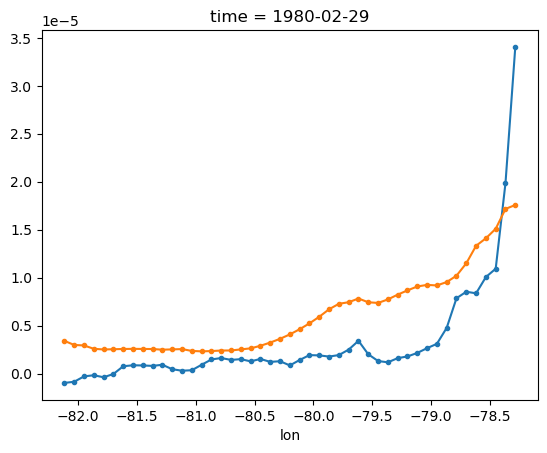

In [106]:
wmld.WMLD.isel(time=1).sel(lat=slice(-10,-7)).mean('lat',skipna=True).plot(marker='.')
AV.isel(time=1).sel(lat=slice(-10,-7)).mean('lat',skipna=True).plot(marker='.')

In [107]:
import numpy as np

R = 6371000.0

# convert degree spacing to radians
dlon = np.deg2rad(1/12)

# latitude in radians (2D or 1D broadcastable)
lat_rad = np.deg2rad(AV['lat'])

# dx (meters), varies with latitude
dx = R * np.cos(lat_rad) * dlon

In [108]:
wmld = xr.open_dataset('../W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, var='WMLD', target_width_km=mask_km)
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
wmld

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

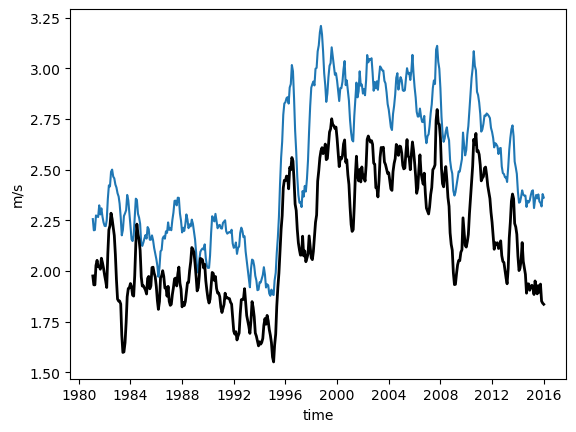

In [109]:

(AV * dx).sum(dim='lon').mean(dim='lat').rolling(time=13).mean().plot()
(wmld * dx).sum(dim='lon').mean(dim='lat').WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')

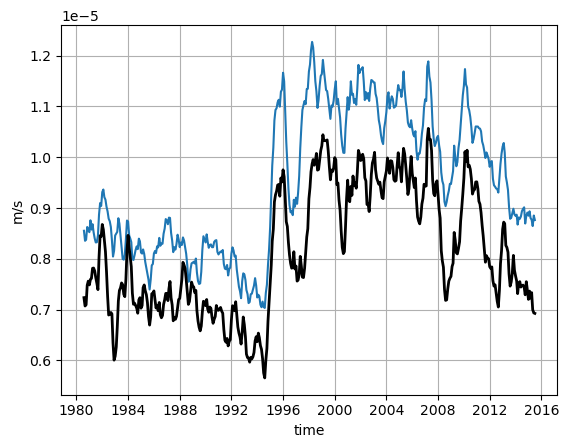

In [110]:
AV.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).rolling(time=13,center=True).mean().plot()
wmld.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rolling(time=13,center=True).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

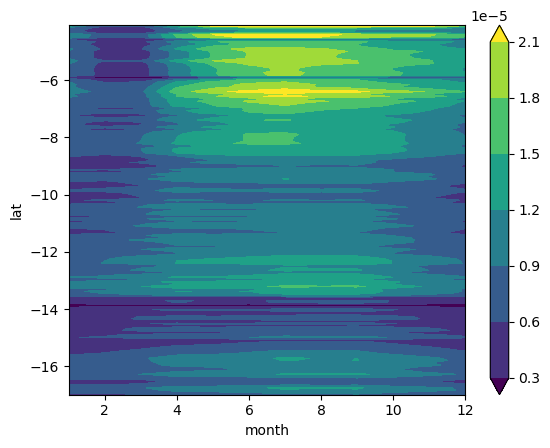

In [111]:
seasonality(AV).mean('lon').plot.contourf(x='month',robust=True)

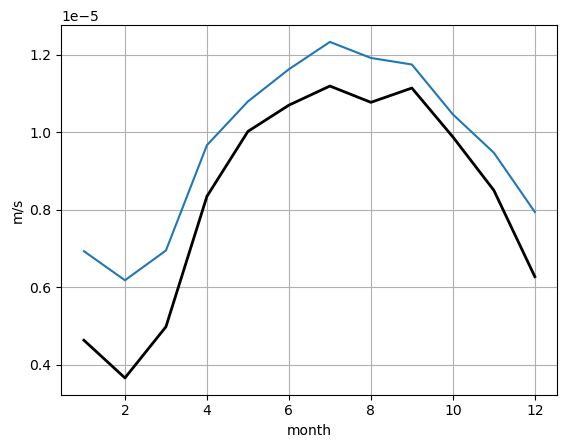

In [112]:
seasonality(AV).mean(dim=('lon','lat')).plot()
seasonality(wmld).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

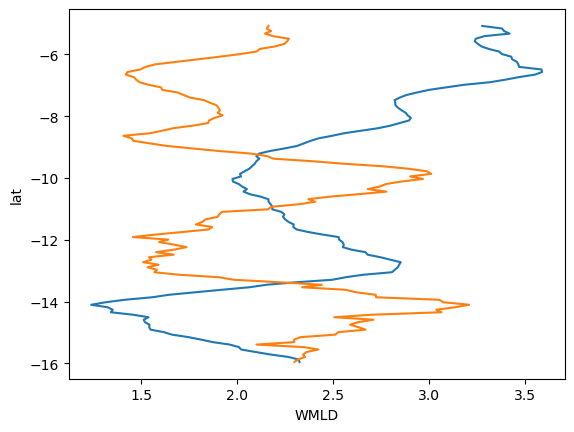

In [113]:
(AV * dx).sum(dim='lon').mean(dim=('time')).rolling(
    lat=13,center=True).mean().sel(lat=slice(-16,-5)).plot(y='lat')
(wmld * dx).sum(dim='lon').WMLD.mean(dim=('time')).rolling(
    lat=13,center=True).mean().sel(lat=slice(-16,-5)).plot(y='lat')

## Another Ekman Pump
* Pump calculated by finite differences

In [114]:
ekpump = xr.open_dataset('Ekman_pumping.nc').compute()
ekpump

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 541, time: 432, lon: 601)
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 1GB 2.724e-07 3.15e-07 ... nan nan

In [115]:
mask_pump = coastal_band_mask(ekpump,'w_ek',mask_km)
ekpump=ekpump.where(mask_pump).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
ekpump

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lat      (lat) float64 1kB -16.95 -16.87 -16.79 ... -4.204 -4.121 -4.038
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.99 -84.91 -84.83 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [267]:
def get_custom_band(ds,variable, inner_km, outer_km):
    """Returns the interval between two distances."""
    inner = coastal_band_mask(ds,var='w_ek' ,target_width_km=inner_km)
    outer = coastal_band_mask(ds,var='w_ek' ,target_width_km=outer_km)
    return outer & (~inner)

In [268]:
offshore_band = get_custom_band(ekpump,'w_ek', 0, 250)
ekpump_ = ekpump.where(offshore_band)

Text(0.5, 1.0, 'All Ekpumping')

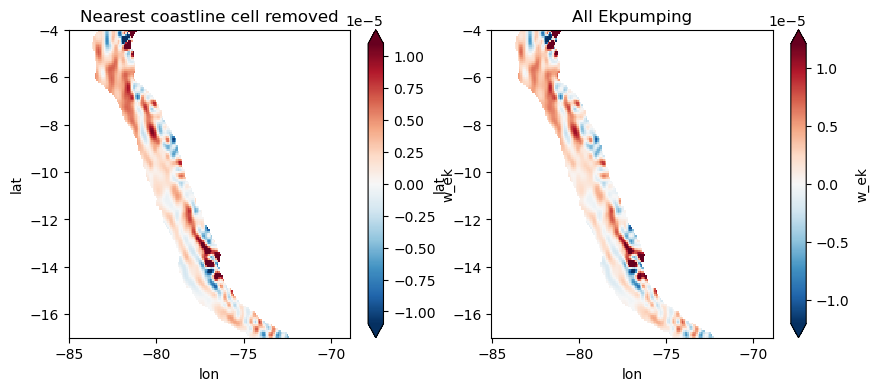

In [269]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

ekpump_.w_ek.mean('time').plot(robust=True,ax=ax[0])
ekpump.w_ek.mean('time').plot(robust=True,ax=ax[1])

ax[0].set_title('Nearest coastline cell removed')
ax[1].set_title('All Ekpumping')

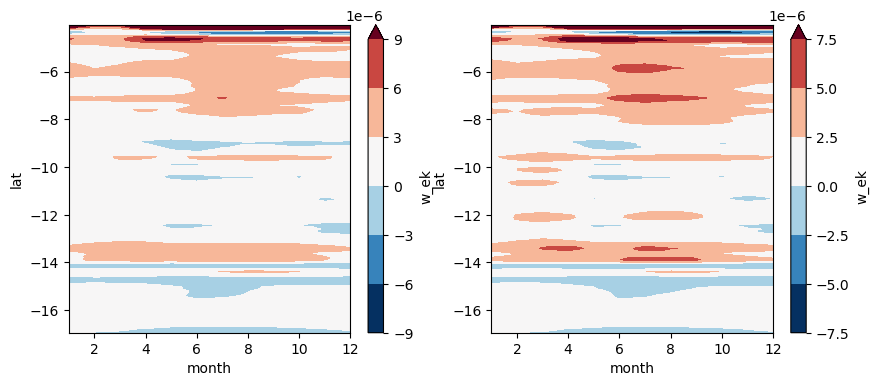

In [270]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

seasonality(ekpump.w_ek).mean('lon').plot.contourf(x='month',robust=True,ax=ax[0])
seasonality(ekpump_.w_ek).mean('lon').plot.contourf(x='month',robust=True,ax=ax[1])

In [271]:
# Wc.lat
# ekpump_centered = ((ekpump.w_ek.shift(lat=-1) + ekpump.w_ek) * 0.5).isel(lat=slice(0, -1))
ekpump_centered = ekpump_.w_ek
ekpump_centered = ekpump_centered.assign_coords(lat=Wc.lat, lon=Wc.lon)
ekpump_centered 

<xarray.DataArray 'w_ek' (time: 432, lat: 159, lon: 194)> Size: 107MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

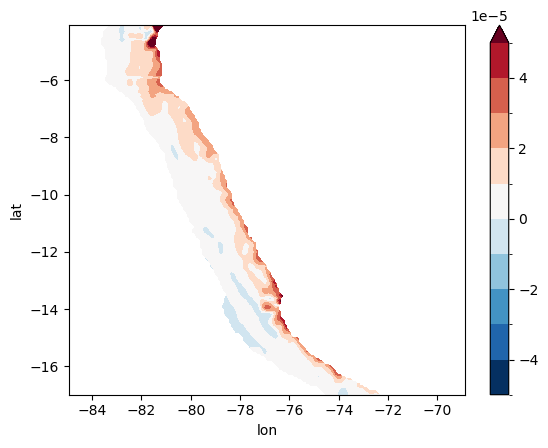

In [272]:
(ekpump_centered + Wc).mean('time').plot.contourf(vmin=-5e-5,vmax=5e-5,levels=11,cmap='RdBu_r')

In [273]:
AV_ = ekpump_centered + Wc
AV_

<xarray.DataArray (time: 432, lat: 159, lon: 194)> Size: 107MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

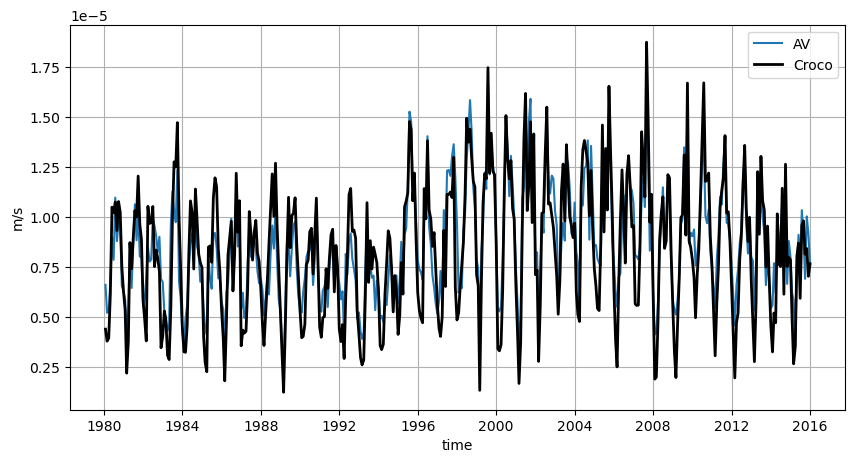

In [274]:
# AV_.mean(dim=('lon','lat')).AV.plot(figsize=(10,5),label='AV')
AV_.mean(dim=('lon','lat')).plot(figsize=(10,5),label='AV')
wmld.mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)
plt.legend()

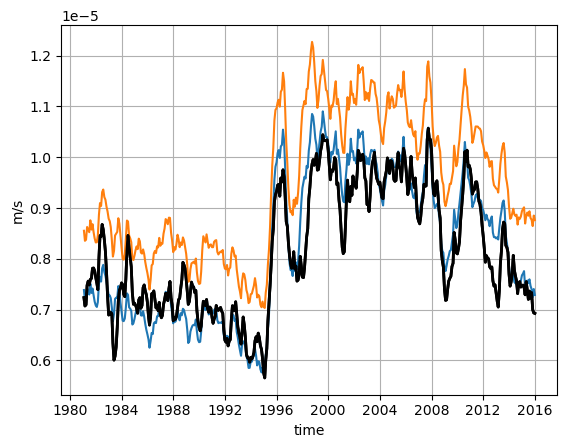

In [275]:
AV_.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).rolling(time=13).mean().plot()
wmld.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

AV.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).rolling(time=13).mean().plot()
wmld.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

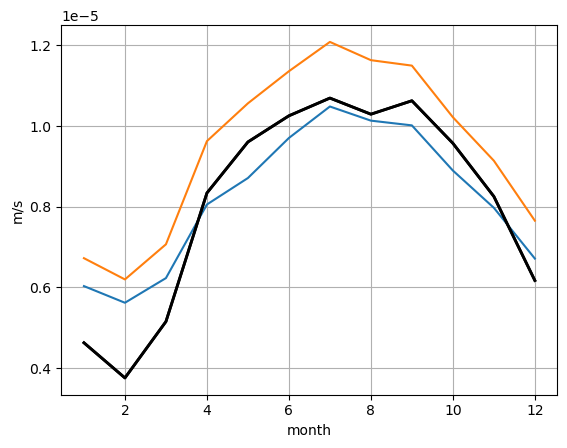

In [276]:
seasonality(AV_).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

seasonality(AV).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)

In [277]:
AV_ = AV_.to_dataset(name='AV')
AV_

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
Data variables:
    AV       (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [278]:
AV_['Epumping'] = ekpump_centered
AV_['Wc'] = Wc

In [285]:
# AV_.to_netcdf('AV.nc')

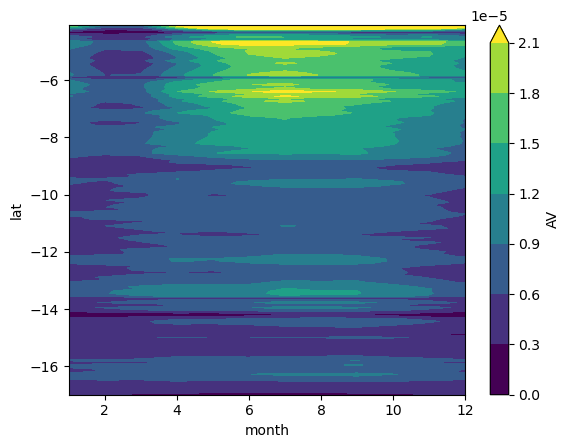

In [280]:
seasonality(AV_).AV.mean('lon').plot.contourf(y='lat',robust=True)

(-5e-06, 2e-05)

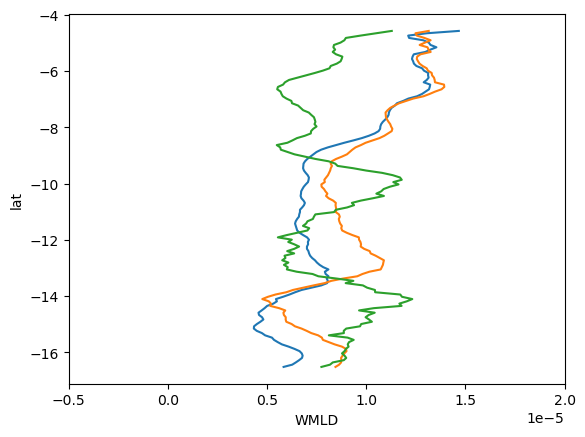

In [281]:
AV_.AV.mean(dim=('time','lon')).rolling(lat=13,center=True).mean().sel(lat=slice(lati2,lati1)).plot(y='lat')
AV.mean(dim=('time','lon')).rolling(lat=13,center=True).mean().sel(lat=slice(lati2,lati1)).plot(y='lat')

(wmld).WMLD.mean(dim=('time','lon')).rolling(
    lat=13,center=True).mean().sel(lat=slice(lati2,lati1)).plot(y='lat')

plt.xlim(-0.5e-5, 2e-5)

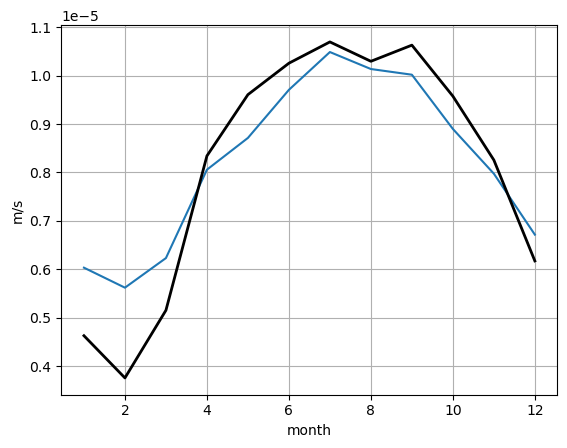

In [282]:
seasonality(AV_.AV).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
plt.grid(True)


In [283]:
AV_ = AV_.assign_coords(
    year=AV.time.dt.year,
    month=AV.time.dt.month
)
AV__ = AV_.set_index(time=['year', 'month']).unstack('time')
AV__

<xarray.Dataset> Size: 320MB
Dimensions:   (year: 36, month: 12, lat: 159, lon: 194)
Coordinates:
  * year      (year) int64 288B 1980 1981 1982 1983 1984 ... 2012 2013 2014 2015
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
Data variables:
    AV        (lat, lon, year, month) float64 107MB nan nan nan ... nan nan nan
    Epumping  (lat, lon, year, month) float64 107MB nan nan nan ... nan nan nan
    Wc        (lat, lon, year, month) float64 107MB nan nan nan ... nan nan nan

Text(0.5, 1.0, '$AV$')

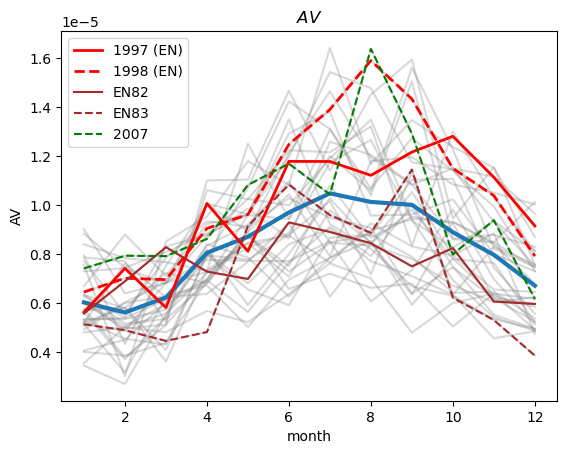

In [284]:
data = AV__.AV.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'))

data.plot(
    x='month', 
    hue='year',      # This keeps the lines separated by year
    add_legend=False, # This hides the legend
    color='gray',
    alpha=0.3# This may be overridden by the hue cycle, see note below
)

seasonality(AV_.AV).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).plot(linewidth=3)
# 3. Plot highlighted years (Red for 1997-1998)
data.sel(year=1997).plot(
    x='month', 
    color='red', 
    linestyle='-', 
    linewidth=2, 
    label='1997 (EN)'
)

# 2. Plot 1998 as a dashed line
data.sel(year=1998).plot(
    x='month', 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label='1998 (EN)'
)
# 4. Plot highlighted years (Brown for 1982-1983)
# Plot 1982 (Red, Dashed)
data.sel(year=1982).plot(x='month', color='brown', linestyle='-', label='EN82')

# Plot 1983 (Brown, Dotted)
data.sel(year=1983).plot(x='month', color='brown', linestyle='--', label='EN83')

data.sel(year=2007).plot(x='month', color='green', linestyle='--', label='2007')

plt.legend()
plt.title('$AV$')